<a href="https://colab.research.google.com/github/jomanakhatib/Projects-/blob/main/Regression_Mini_Project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name:

ID:

Tutorial:

---

Name:

ID:

Tutorial:

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [52]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')
print("First 5 rows")
display(df.head())
print("Last 5 rows")
display(df.tail())
print("Counts number of rows and columns")
display(df.shape)
print("Summary of column details")
display(df.describe())
print("Gets out the column type and counts non null values per column")
display(df.info())
print("Count missing values per column")
display(df.isnull().sum())






First 5 rows


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


Last 5 rows


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
1095,BLD-2095-OH,Commercial,Giza,(Dokki50,Saturday,High,Low,1161m2,2022-04-21,27.85,3010.81 kWh
1096,BLD-2096-RH,Residential,NaN,Dokki-71,Sunday,Medium,Medium,37943m2,2024-10-31,36.23,4248.49 kWh
1097,BLD-2097-JZ,Commercial,Giza,_Mohandessin91,SunDay,Low,Medium,1558,2021-04-18,20.00,2843.6 kWh
1098,BLD-2098-ZP,Industrial,Alexandria,*23Smouha,saturday,Medium,Low,2145,2023-09-14,34.43,3348.39 kWh
1099,BLD-2099-GL,Residential,Cairo,-New Cairo52,friDAY,High,Medium,42414,2020-12-09,40.37,4722.59 kWh


Counts number of rows and columns


...

,Average_Temperature
count,990.000000
mean,33.499404
std,10.703806
min,-4.910000
25%,29.422500
50%,35.260000
75%,39.970000
max,50.000000


Gets out the column type and counts non null values per column
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB


None

Count missing values per column


,0
Building_ID,0
Building_Type,110
Governorate,227
Neighborhood,0
Day_of_Week,0
Occupancy_Level,0
Appliances_Usage_Level,0
SquareFootage,0
Last_Maintenance_Date,0
Average_Temperature,110


## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

In [53]:

import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')
print("Dataset loaded successfully. Original shape:", df.shape)

# Remove extra characters & clean whitespace
df = df.replace({r'\u00a0': ' '}, regex=True)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

#Normalize categorical text
text_cols = ["Building_Type", "Governorate", "Neighborhood",
             "Day_of_Week", "Occupancy_Level", "Appliances_Usage_Level"]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^A-Za-z\s]', '', regex=True)  # remove symbols and numbers
            .str.lower()
            .str.title()                                 # Captilize first letter per word
            .replace('Nan', np.nan)                      # replace 'Nan' to most freq category
        )

# if governante is missing then we chould check the neighborhood and compare with the same neighborhood in other row then infere it and replace it in the missing one
gov_map = (
    df.groupby("Neighborhood")["Governorate"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).dropna().to_dict()
)
mask = df["Governorate"].isna() & df["Neighborhood"].notna()
df.loc[mask, "Governorate"] = df.loc[mask, "Neighborhood"].map(gov_map)

# Clean numeric columns by removing any text units and special symbols
df['SquareFootage'] = (
    df['SquareFootage']
    .astype(str)
    .str.replace('m2', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

df['Energy_Consumption'] = (
    df['Energy_Consumption']
    .astype(str)
    .str.replace('kWh', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

#Convert date column to datetime in order to be used in Days_since_last_maintenance column
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'], errors='coerce')

#Handle missing values
# In Numeric columns by replacing with mean
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

#In Categorical columns by replacing with mode
cat_cols = df.select_dtypes(exclude='number').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#Feature Engineering
# a) Days since last maintenance
df['Days_since_last_maintenance'] = (
    pd.to_datetime('2025-10-01') - df['Last_Maintenance_Date']
).dt.days

# b) Day_type (Weekday/Weekend)
df['Day_type'] = df['Day_of_Week'].apply(
    lambda x: 'Weekend' if x in ['Friday', 'Saturday'] else 'Weekday'
)

display(df.head(6))
display(df.tail())

Dataset loaded successfully. Original shape: (1100, 11)


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Day_type
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.610000,2713.95,2100,Weekday
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,33.499404,5744.99,1315,Weekday
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.880000,4101.24,1682,Weekday
3,BLD-1003-HE,Residential,Giza,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.060000,3009.14,794,Weekday
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.820000,3279.17,1146,Weekday
5,BLD-1005-VX,Commercial,Cairo,New Cairo,Sunday,Low,Medium,37377.0,2022-07-31,37.540000,4687.67,1158,Weekday


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Day_type
1095,BLD-2095-OH,Commercial,Giza,Dokki,Saturday,High,Low,1161.0,2022-04-21,27.85,3010.81,1259,Weekend
1096,BLD-2096-RH,Residential,Giza,Dokki,Sunday,Medium,Medium,37943.0,2024-10-31,36.23,4248.49,335,Weekday
1097,BLD-2097-JZ,Commercial,Giza,Mohandessin,Sunday,Low,Medium,1558.0,2021-04-18,20.00,2843.60,1627,Weekday
1098,BLD-2098-ZP,Industrial,Alexandria,Smouha,Saturday,Medium,Low,2145.0,2023-09-14,34.43,3348.39,748,Weekend
1099,BLD-2099-GL,Residential,Cairo,New Cairo,Friday,High,Medium,42414.0,2020-12-09,40.37,4722.59,1757,Weekend


## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

Top 3 most popular neighborhoods:
 Neighborhood
Smouha    199
Dokki     194
Gleem     189
Name: count, dtype: int64


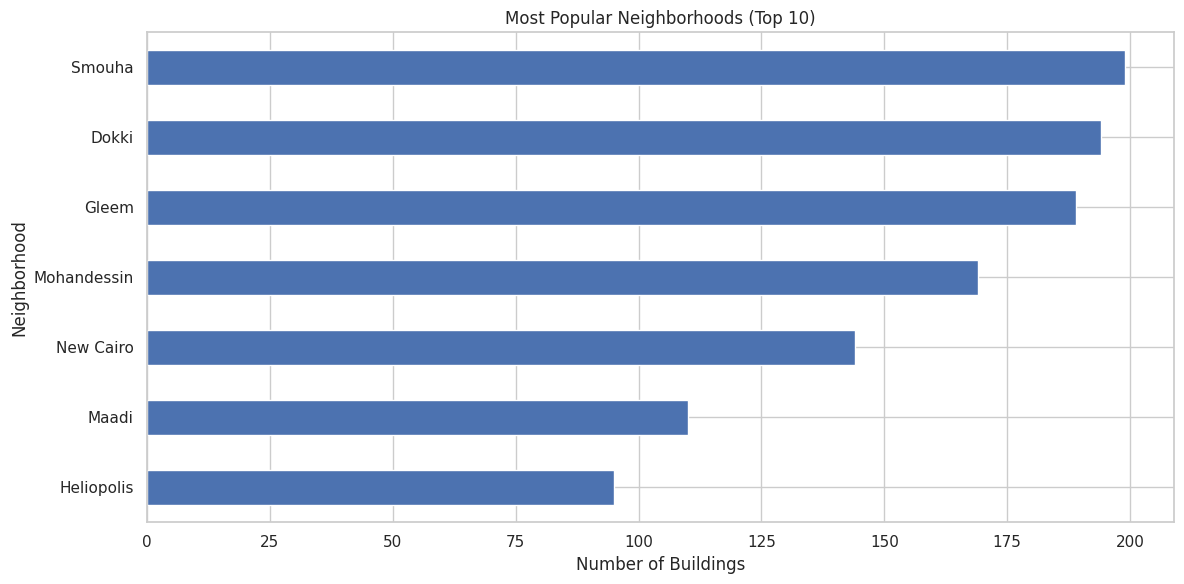

In [54]:
import matplotlib.pyplot as plt #Data visualization library

#Count the total number neighborhood
neighborhood_counts = df['Neighborhood'].value_counts()

#Get the top 3 most frequent neighborhoods
top_3_neighborhoods = neighborhood_counts.head(3)
print("Top 3 most popular neighborhoods:\n", top_3_neighborhoods)

#Create a horizontal bar plot to visualize neighborhood popularity
plt.figure(figsize=(12, 6))
#Sort the top 10 neighbourhoods in ascending order,placing the largest at the top.
neighborhood_counts.head(10).sort_values(ascending=True).plot(kind='barh')
plt.title('Most Popular Neighborhoods (Top 10)')
plt.xlabel('Number of Buildings')
plt.ylabel('Neighborhood')
plt.tight_layout() #In order to prevent overlapping of data adjust the layout
plt.show() #for displaying the plot graph model

**Answer for Q1:** _Your answer here_

In order to visualize the most popular neighborhoods we had analyzed the frequency of buildings located in each neighborhood by getting the top 3 most popular neighborhoods and in order to visualize the results we use bar chart as it's perfectly fits out the idea of comparing categorical data  



**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

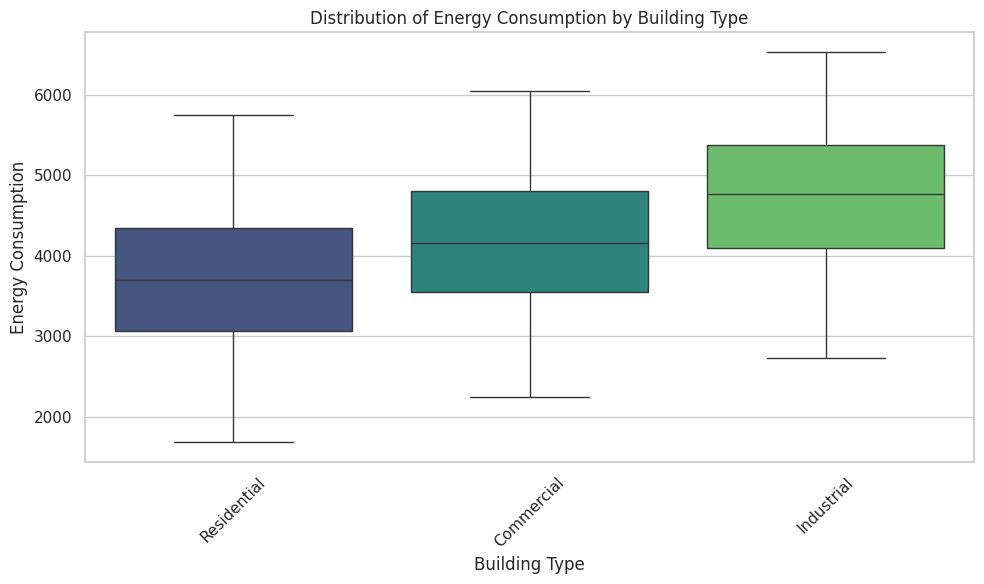

Average Energy Consumption per Building Type:


,Energy_Consumption
Building_Type,
Industrial,4708.418671
Commercial,4170.374462
Residential,3679.396934


Range (Max - Min) of Energy Consumption per Building Type:


,Energy_Consumption
Building_Type,
Residential,4062.45
Industrial,3805.78
Commercial,3800.60


In [55]:
import pandas as pd
import matplotlib.pyplot as plt #Import plotting method for visualization
import seaborn as sns
import numpy as np

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

# Clean numeric columns by removing any text units and special symbols
df['Energy_Consumption'] = (
    df['Energy_Consumption']
    .astype(str)
    .str.replace('kWh', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)
#Handle missing values in numeric columns by replacing with mean
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

sns.set(style="whitegrid") #This is for setting the a white background for better visualization of gride displayed
plt.figure(figsize=(10,6)) # This is for setting figure size
sns.boxplot(x='Building_Type', y='Energy_Consumption', hue='Building_Type', data=df, palette='viridis', legend=False)#Plots the distribution of energy consumption for each Building_Type and'hue'ensures color consistency.
# Add title and labels
plt.title('Distribution of Energy Consumption by Building Type', fontsize=12)
plt.xlabel('Building Type')
plt.ylabel('Energy Consumption')
plt.xticks(rotation=45) #rotates the data to be easily read
plt.tight_layout() #Adjusts spacing for a neat layout and for preventing any cutouts.
plt.show()

#Calculate average energy consumption per building type
avg_consumption = df.groupby('Building_Type')['Energy_Consumption'].mean().sort_values(ascending=False)
print("Average Energy Consumption per Building Type:")
display(avg_consumption)

#Calculate the range (distribution width) of each building type ---
range_consumption = df.groupby('Building_Type')['Energy_Consumption'].apply(lambda x: x.max() - x.min()).sort_values(ascending=False)
print("Range (Max - Min) of Energy Consumption per Building Type:")
display(range_consumption)

**Answer for Q2:**The above code has cleaned the data from "kWh"in the Energy_Consumption column, converts it numeric value of type float and replaces the missing values with the mean per column to ensure there is no NAN.We have two buldings types commercial or industrial upon the boxplot it visualizes the most Industrial building type that has the widest distribution of energy consumption. The Industrial has the highest average as it consumes the most energy overall and commercial has the widest range as it shows the most variability in energy usage. The are two calculations one that calculates the average 'mean' energy consumption for each building type and the other one is the range(difference between maximum and minimum) for each type indicating which has the widest distribution.

**Q3:** How does the building size affect energy consumption?

**Visualization**

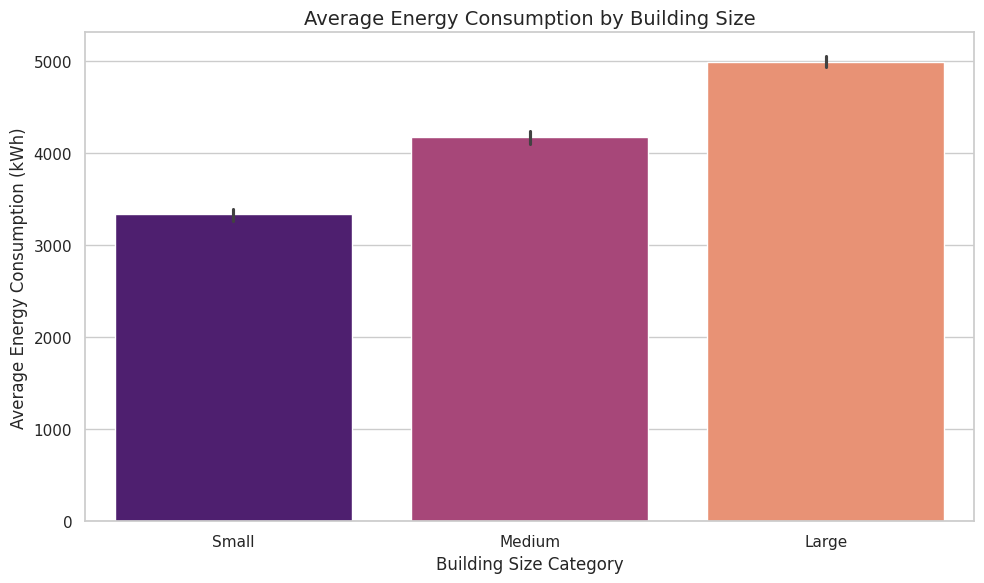

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataframe if it's not already defined
try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

# Clean the 'SquareFootage' column
df['SquareFootage'] = (
    df['SquareFootage']
    .astype(str)
    .str.replace('m2', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

# Impute missing values in 'SquareFootage'
df['SquareFootage'] = df['SquareFootage'].fillna(df['SquareFootage'].mean())


# Create 'Size_Category' column
df['Size_Category'] = pd.qcut(df['SquareFootage'], q=3, labels=['Small', 'Medium', 'Large'])

# Clean 'Energy_Consumption' column
df['Energy_Consumption'] = (
    df['Energy_Consumption']
    .astype(str)
    .str.replace('kWh', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

# Impute missing values in 'Energy_Consumption'
df['Energy_Consumption'] = df['Energy_Consumption'].fillna(df['Energy_Consumption'].mean())


#chose barplot to make it easier to the eye to detcet the diffrences and detect the trends
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Size_Category',
    y='Energy_Consumption',
    hue='Size_Category', #categories
    palette='magma',#color schema
    legend=False #hide redundant colors
)
#plot the axis
plt.title('Average Energy Consumption by Building Size', fontsize=14)
plt.xlabel('Building Size Category')
plt.ylabel('Average Energy Consumption (kWh)')
plt.tight_layout()
plt.show()

**Answer for Q3:According to what we intreferd from the barplot that the builidng size is positevly correalted to the average energy consumtion, as the building size go bigger the energy consumptions increases;it'll need more equipments and facilities

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

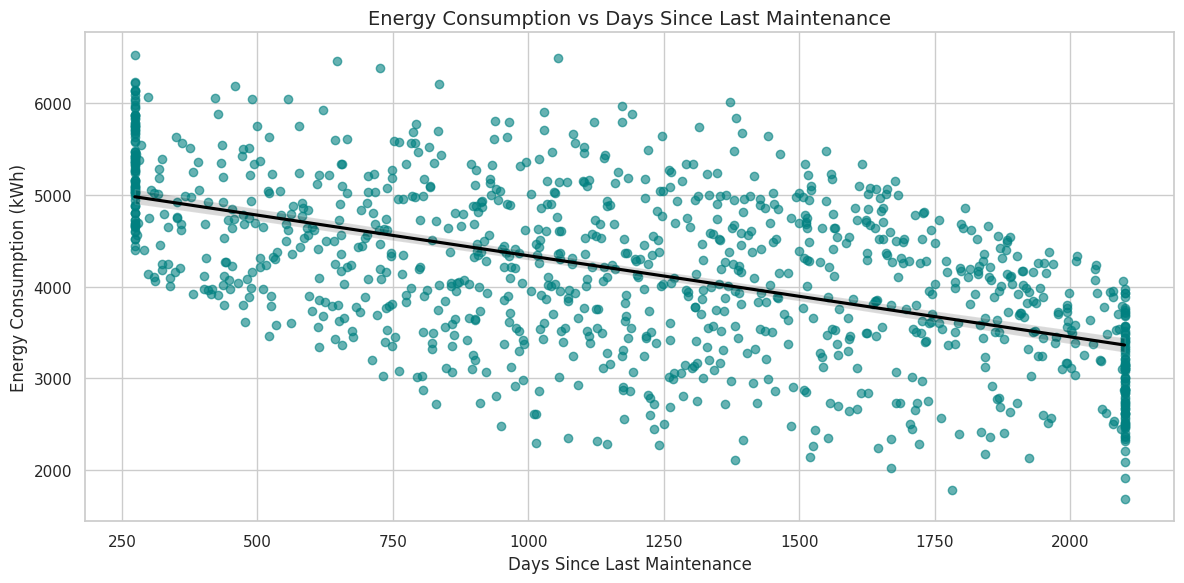

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataframe if it's not already defined
try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

# Include preprocessing steps to create 'Days_since_last_maintenance'
# Clean numeric columns by removing any text units and special symbols
df['SquareFootage'] = (
    df['SquareFootage']
    .astype(str)
    .str.replace('m2', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

df['Energy_Consumption'] = (
    df['Energy_Consumption']
    .astype(str)
    .str.replace('kWh', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

#Convert date column to datetime in order to be used in Days_since_last_maintenance column
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'], errors='coerce')

#Handle missing values
# In Numeric columns by replacing with mean
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

#In Categorical columns by replacing with mode
cat_cols = df.select_dtypes(exclude='number').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


#Feature Engineering
# a) Days since last maintenance
df['Days_since_last_maintenance'] = (
    pd.to_datetime('2025-10-01') - df['Last_Maintenance_Date']
).dt.days


sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

# Scatter plot with best fitting line
sns.regplot(
    data=df,
    x='Days_since_last_maintenance',
    y='Energy_Consumption',
    scatter_kws={'alpha':0.6, 'color':'teal'},   # scatter dots
    line_kws={'color':'black'}                   # the best line fitting
)
#x axis and y axis
plt.title('Energy Consumption vs Days Since Last Maintenance', fontsize=14)
plt.xlabel('Days Since Last Maintenance')
plt.ylabel('Energy Consumption (kWh)')
plt.tight_layout()
plt.show()

**Answer for Q4:** According to the scatter plot there's a positive relationship between number of days since last maintenance and the building’s energy consumption.
This means that ; when the number of days since last maintenance increase this will increase the energy consumption

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

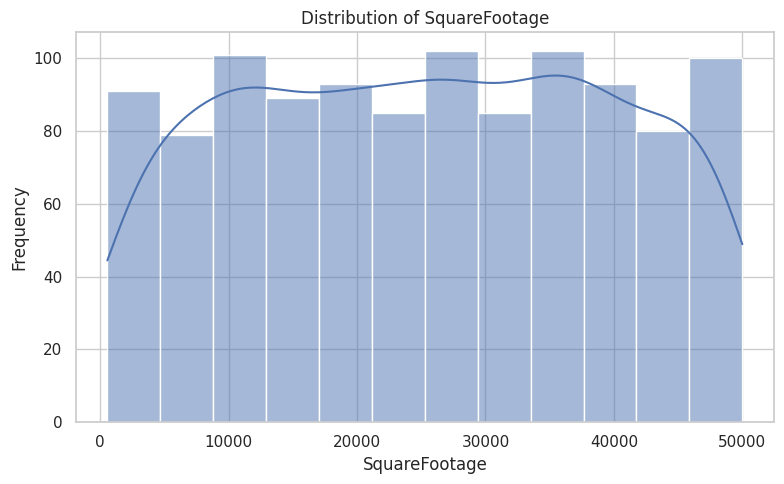

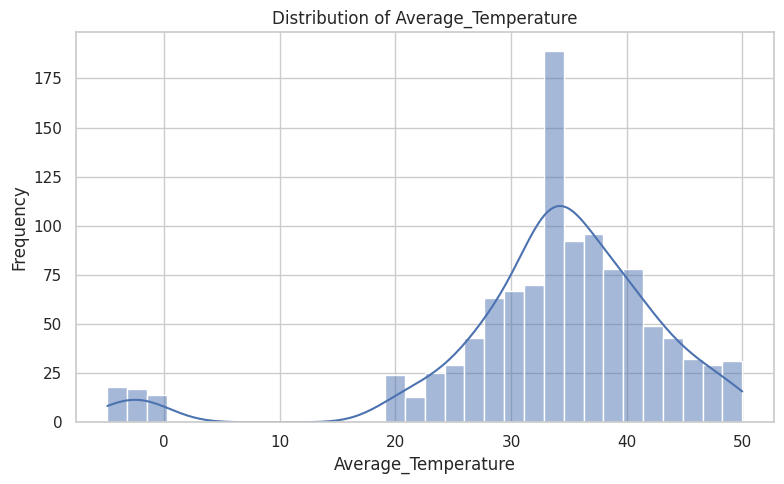

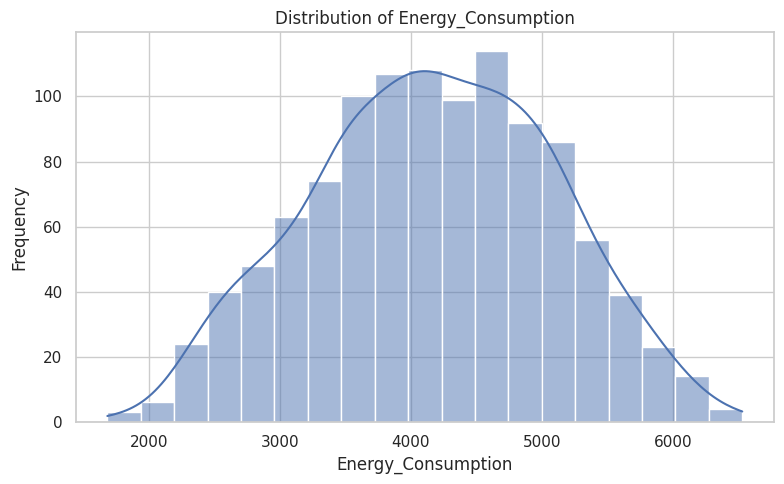

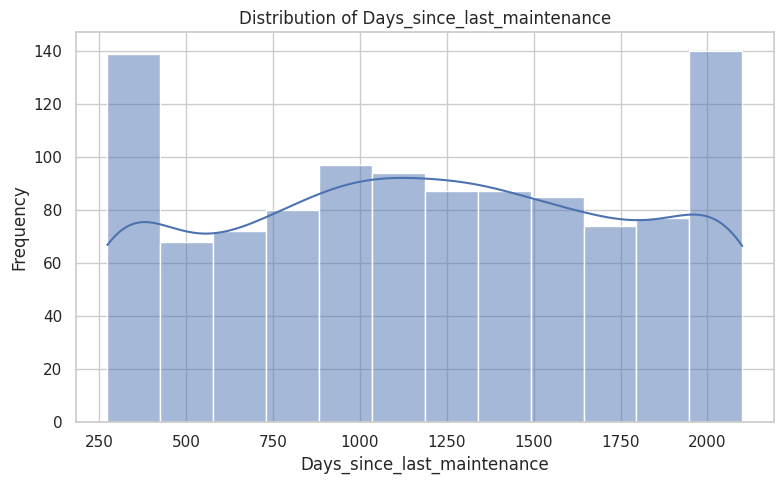

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns #by filtering out text or categorical columns, extraxting column namesthen extracts these column names and then list down all numeric columns

# Plot histograms for each numerical column
for col in numerical_cols: #It loops on each numeric column in the DataFrame and creates a histogram
    plt.figure(figsize=(8, 5)) #creating anew figure for the histogram and prevents the plotting from overlapping
    sns.histplot(data=df, x=col, kde=True) #for creating a histogram for a specific column
    plt.title(f'Distribution of {col}') #for adding a title for each column named in order to allow 'f-string'to insert the variable name directly
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

**Answer for Q5:**From analysing the above two histograms and the calculated skewness values, this showed that the Average Temperature is left-skewed (skewness = -1.7956) and Energy_Consumption is approximately normally distributed (skewness = -0.0602).
First thing we import for plotting to visualize the diagram then we select the numeric cols only in order to filter out text or categorical columns, extraxting column namesthen extracts these column names and then list down all numeric columns.Then the data is of two types whether it's skewed or nomally distributed so we start by plotting a histogram for each numeric column and kde'Kernel Density Estimate' is used in Seaborn’s to add a curved line on top of your bars to help visualize the overall shape of your data in order to show the datafram wher#ther it's normally distributed or skewed.

**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

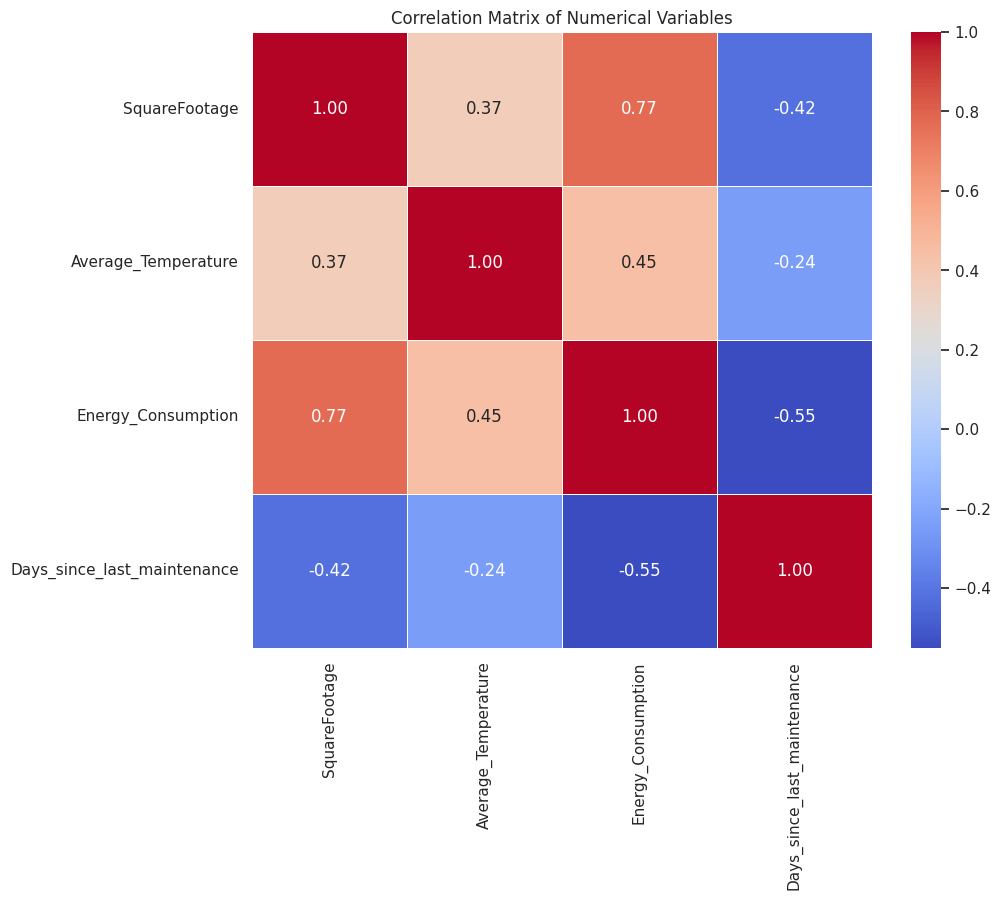

In [59]:
#Calaculating the correlation matrix for numerical attributes
numerical_cols = df.select_dtypes(include=np.number).columns #Selects only numeric columns (e.g., temperature, square footage, energy consumption, etc.) to avoid including categorical text data in the correlation matrix.
corr_matrix = df[numerical_cols].corr() #Calculates the Pearson correlation coefficients between all pairs of numerical variables.

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

**Answer for Q6:**Multicollinearity is when two or more independent(predictor) variables in a regression model are highly correlated with each other and this means that they are similar to each other.This results in a linear regression as the model finds it difficult to know the individual effect of each predictor on the dependent variable. As a result, the coefficients become unstable, their standard errors increase, and the model's interpretability and predictive accuracy decrease. Essentially, multicollinearity doesn't affect the overall prediction power much, but it makes it hard to trust which variables are actually important.Thus, this problem exist in this dataset which is examined by the above heatmap which looks ou for values close to 1 or -1 and these predictor values are (Average_Temperature, SquareFootage, and Days_since_last_maintenance) while the Energy_Consumption is a target variable so its correlation is predicatable and does not indicate multicollinearity among the predictors themselves.The code is for assessing the idea of multicollinearity by selecting first  only numerical columns where this ensures that only quantitative variables (like temperature, square footage, or energy consumption) are analyzed, excluding categorical data and then applying the correlation matrix funtion which computes the Pearson correlation coefficients between every pair of numerical variables. Finally, a heatmap helps identify pairs of variables with high correlation values. Such strong correlations indicate potential multicollinearity, and allow us to decide whether to remove redundant variables or apply dimensionality reduction before running linear regression.

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

In [60]:
# ===== EXACT LAB-STYLE PIPELINE, APPLIED TO YOUR ENERGY DATA =====

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- 0) Minimal cleaning so columns are usable like in the lab ---
# If units exist, strip them so columns are numeric
if df['Energy_Consumption'].dtype == 'object':
    df['Energy_Consumption'] = (
        df['Energy_Consumption'].astype(str)
        .str.replace('kWh', '', regex=False)
        .str.replace('[^0-9.]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

if 'SquareFootage' in df.columns and df['SquareFootage'].dtype == 'object':
    df['SquareFootage'] = (
        df['SquareFootage'].astype(str)
        .str.replace('m2', '', regex=False)
        .str.replace('[^0-9.]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

# --- 1) Categorical columns (like lab's ['sex','smoker','region']) ---
categorical_columns = ['Building_Type', 'Governorate', 'Occupancy_Level', 'Appliances_Usage_Level']

# Keep only the ones that actually exist in df (so it won't error if a column is missing)
categorical_columns = [c for c in categorical_columns if c in df.columns]

df_encode = pd.get_dummies(
    data=df,
    columns=categorical_columns,
    drop_first=True,
    dtype='int8'
)

# --- 2) Show columns before/after (like the lab) ---
print('Columns in original data frame:\n', df.columns.values)
print('\nNumber of rows and columns in the data set:', df.shape)

print('\nColumns in data frame after encoding dummy variable:\n', df_encode.columns.values)

# --- 3) Numerical columns to scale with Min–Max (like lab's ['age','bmi','children']) ---
# Use the key continuous drivers available in your dataset
numerical_columns = ['SquareFootage', 'Average_Temperature']
numerical_columns = [c for c in numerical_columns if c in df_encode.columns]

if numerical_columns:
    df_encode[numerical_columns] = (
        df_encode[numerical_columns] - df_encode[numerical_columns].min()
    ) / (
        df_encode[numerical_columns].max() - df_encode[numerical_columns].min()
    )

# --- 4) Preview head and final shape (like the lab) ---
display(df_encode.head())
print('\nNumber of rows and columns in the dataset:', df_encode.shape)

# --- 5) Train/Test split (same as lab: test_size=0.2, random_state=23) ---
x = df_encode.drop('Energy_Consumption', axis=1)  # Independent variables
y = df_encode['Energy_Consumption']                # Dependent variable

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=23
)

print('Training dataset size:', x_train.shape[0])
print('Testing  dataset size:', x_test.shape[0])

Columns in original data frame:
 ['Building_ID' 'Building_Type' 'Governorate' 'Neighborhood' 'Day_of_Week'
 'Occupancy_Level' 'Appliances_Usage_Level' 'SquareFootage'
 'Last_Maintenance_Date' 'Average_Temperature' 'Energy_Consumption'
 'Days_since_last_maintenance']

Number of rows and columns in the data set: (1100, 12)

Columns in data frame after encoding dummy variable:
 ['Building_ID' 'Neighborhood' 'Day_of_Week' 'SquareFootage'
 'Last_Maintenance_Date' 'Average_Temperature' 'Energy_Consumption'
 'Days_since_last_maintenance' 'Building_Type_Industrial'
 'Building_Type_Residential' 'Governorate_Cairo' 'Governorate_Giza'
 'Occupancy_Level_Low' 'Occupancy_Level_Medium'
 'Appliances_Usage_Level_Low' 'Appliances_Usage_Level_Medium']


,Building_ID,Neighborhood,Day_of_Week,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Building_Type_Industrial,Building_Type_Residential,Governorate_Cairo,Governorate_Giza,Occupancy_Level_Low,Occupancy_Level_Medium,Appliances_Usage_Level_Low,Appliances_Usage_Level_Medium
0,BLD-1000-UD,Smouha,WeDnesday,0.131541,2020-01-01,0.610453,2713.95,2100,0,1,0,0,0,0,1,0
1,BLD-1001-AX,+Mohandessin14,tuesDAY,0.886219,2022-02-24,0.699497,5744.99,1315,0,0,0,1,0,0,0,0
2,BLD-1002-IH,New Cairo,SunDay,0.378158,2021-02-22,0.779275,4101.24,1682,1,0,1,0,0,1,1,0
3,BLD-1003-HE,+92Dokki,TuesDay,0.256994,2023-07-30,0.727918,3009.14,794,0,1,0,0,1,0,0,0
4,BLD-1004-XD,Smouha,Monday,0.259219,2022-08-12,0.614278,3279.17,1146,0,0,0,0,1,0,1,0



Number of rows and columns in the dataset: (1100, 16)
Training dataset size: 880
Testing  dataset size: 220


## Modelling

_Apply the linear regression model below._

In [61]:
# ===== FIX & FIT: Auto-encode leftover strings, then lab-style parameter table =====
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Reload the dataset as the previous cell was not executed
try:
    df_mod = pd.read_csv('energy_data.csv')
except:
    df_mod = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

# 0) Make sure target and key numerics are numeric
if df_mod['Energy_Consumption'].dtype == 'object':
    df_mod['Energy_Consumption'] = (
        df_mod['Energy_Consumption'].astype(str)
        .str.replace('kWh', '', regex=False)
        .str.replace('[^0-9.]', '', regex=True)
        .replace('', np.nan).astype(float)
    )

if 'SquareFootage' in df_mod.columns and df_mod['SquareFootage'].dtype == 'object':
    df_mod['SquareFootage'] = (
        df_mod['SquareFootage'].astype(str)
        .str.replace('m2', '', regex=False)
        .str.replace('[^0-9.]', '', regex=True)
        .replace('', np.nan).astype(float)
    )

# 1) Build X, y: keep Building_ID for reference only (exclude from features)
y = df_mod['Energy_Consumption']
X_base = df_mod.drop(columns=['Energy_Consumption', 'Building_ID', 'Last_Maintenance_Date'], errors='ignore')


# 2) One-hot encode ANY non-numeric columns still in X (e.g., Day_type = 'Weekday'/'Weekend')
non_numeric_cols = X_base.select_dtypes(exclude=[np.number]).columns.tolist()
X = pd.get_dummies(X_base, columns=non_numeric_cols, drop_first=True, dtype='int8')

# Impute missing values in numerical columns before scaling
numerical_cols_to_impute = X.select_dtypes(include=np.number).columns
for col in numerical_cols_to_impute:
    X[col] = X[col].fillna(X[col].mean())


# (Optional) Min–Max scale a couple of numerics like in the lab
for col in ['SquareFootage', 'Average_Temperature']:
    if col in X.columns:
        col_min = X[col].min()
        col_range = X[col].max() - X[col].min()
        if col_range != 0:
            X[col] = (X[col] - col_min) / col_range


# 3) Split 80/20 exactly like the lab
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=23)

# 4) Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

# 5) Lab-style parameter table (theta_0 = intercept, theta_i = coef_i)
parameter = ['theta_0'] + [f'theta_{i+1}' for i in range(X.shape[1])]
columns   = ['y-intersect'] + list(X.columns.values)
sk_theta  = pd.Series([lin_reg.intercept_] + list(lin_reg.coef_))

parameter_df = pd.DataFrame({
    'parameter': parameter,
    'column': columns,
    'theta_value': sk_theta
})

print("===== Linear Regression Parameters (Energy Model) =====")
display(parameter_df)

===== Linear Regression Parameters (Energy Model) =====


,parameter,column,theta_value
0,theta_0,y-intersect,3503.820926
1,theta_1,SquareFootage,2338.345239
2,theta_2,Average_Temperature,238.778079
3,theta_3,Building_Type_Industrial,467.201508
4,theta_4,Building_Type_Residential,-561.147994
...,...,...,...
894,theta_894,Day_of_Week_wednesday,103.989675
895,theta_895,Occupancy_Level_Low,-682.169707
896,theta_896,Occupancy_Level_Medium,-381.171032
897,theta_897,Appliances_Usage_Level_Low,-706.552370


## Model Evaluation

Evaluate the model you applied.

In [62]:
# ===== Model Evaluation (Energy Consumption Dataset) =====

# sklearn regression module
y_pred = lin_reg.predict(x_test)

# Evaluation

# If you are using a cloud notebook (like Colab), use root_mean_squared_error
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_pred, y_test)

# R_square
R_square = lin_reg.score(x_test, y_test)

print("===== Linear Regression Model Evaluation =====")
print('The root mean square error (RMSE) is: ', round(rmse, 3))
print('R^2 obtained is:', round(R_square, 3))

===== Linear Regression Model Evaluation =====
The root mean square error (RMSE) is:  281.408
R^2 obtained is: 0.911


## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**: your answer here.